In [ ]:
!pip list

Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
accelerate                            1.10.0
aiofiles                              24.1.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.12.15
aiosignal                             1.4.0
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.11.2
altair                                5.5.0
annotated-types                       0.7.0
antlr4-python3-runtime                4.9.3
anyio                                 4.10.0
anywidget                             0.9.18
argon2-cffi                           25.1.0
argon2-cffi-bindings                  25.1.0
array_record                          0.7.2
arviz                                 0.22.0
astropy                               7.1.0
astrop

In [ ]:
#importing useful libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix as cm
import torch
import torch.nn as nn
import torch.optim as opt
import joblib

In [ ]:
dataset = pd.read_csv("Iris.csv")
dataset

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
labelencode = LabelEncoder()
dataset["Species"] = labelencode.fit_transform(dataset["Species"])
dataset

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [ ]:
#splitting data for training and testing
X = dataset.drop("Species", axis = 1)
Y = dataset["Species"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
#Y_train = torch.tensor(Y_train.values, dtype = torch.long)
#Y_test = torch.tensor(Y_test.valuesz, dtype = torch.long)
Y_train = torch.tensor(Y_train.to_numpy(), dtype = torch.long)
Y_test = torch.tensor(Y_test.to_numpy(), dtype = torch.long)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

torch.Size([120, 5])
torch.Size([30, 5])
torch.Size([120])
torch.Size([30])


In [ ]:
#building a 3-layer neural network
class neural_network(nn.Module):
  def __init__(self):
    super(neural_network, self).__init__()
    self.layer1 = nn.Linear(5, 10)
    self.layer2 = nn.Linear(10, 10)
    self.layer3 = nn.Linear(10, 3)
    self.relu = nn.ReLU()

  def forward(self, X):
    output = self.layer1(X)
    output2 = self.relu(output)
    output3 = self.layer2(output2)
    output4 = self.relu(output3)
    output5 = self.layer3(output4)
    return output5

DL_Model = neural_network()

In [ ]:
#initializing loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = opt.Adam(DL_Model.parameters(), lr = 0.01)

In [ ]:
#training model using 100 complete iterations
epoch = 100
for ep in range(epoch):
  Output = DL_Model(X_train)
  loss = loss_function(Output, Y_train)

  if ep % 10 == 0:
    print("Epoch: ", ep, "Loss: ", loss.item())

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

Epoch:  0 Loss:  1.1139084100723267
Epoch:  10 Loss:  0.7954215407371521
Epoch:  20 Loss:  0.4682890474796295
Epoch:  30 Loss:  0.23254413902759552
Epoch:  40 Loss:  0.08975031971931458
Epoch:  50 Loss:  0.028780488297343254
Epoch:  60 Loss:  0.011503574438393116
Epoch:  70 Loss:  0.005791439674794674
Epoch:  80 Loss:  0.0036458587273955345
Epoch:  90 Loss:  0.002708102809265256


In [ ]:
#evaluation and accuracy
with torch.no_grad():
  outputs = DL_Model(X_test)
  _, predicted = torch.max(outputs.data, 1)
  accuracy = (predicted == Y_test).sum().item() / len(Y_test)
  print("Accuracy: ", accuracy * 100, "%")

Accuracy:  100.0 %


In [ ]:
print(DL_Model)

neural_network(
  (layer1): Linear(in_features=5, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)


In [ ]:
#classification report
cr = classification_report(Y_test, predicted)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



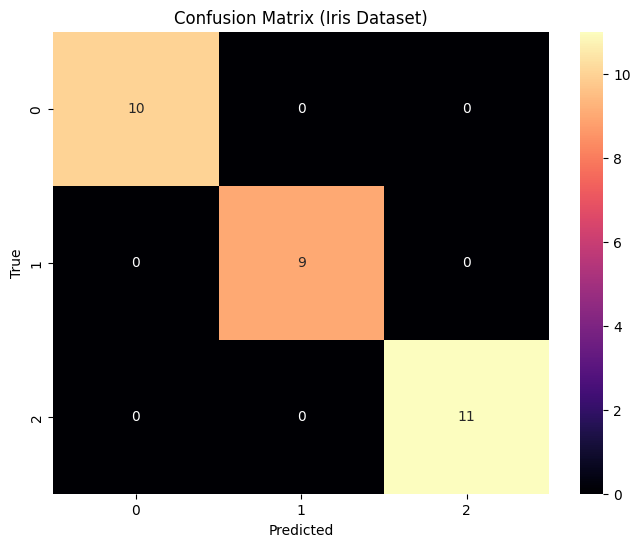

In [ ]:
#confusion matrix
confuse_matrix = cm(Y_test, predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(confuse_matrix, annot=True, fmt='d', cmap = 'magma')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Iris Dataset)')
plt.show()

In [ ]:
joblib.dump(DL_Model, "DL_Model.pkl")
joblib.dump(labelencode, 'label_encoder.pkl')

['label_encoder.pkl']

In [ ]:
!pip install streamlit

In [ ]:
!pip install pyngrok